# Прогноз KRAS Gene Effect: LinearRegression, LightGBM и XGBoost

Цель — построить воспроизводимый baseline и сравнить его с двумя моделями градиентного бустинга:

```text
данные модели → подготовка признаков → обучение моделей → сравнение прогнозов KRAS_GeneEffect
```

Одна строка — одна клеточная модель. Чем отрицательнее `KRAS_GeneEffect`, тем сильнее эффект нокаута KRAS.

Все операции подготовки находятся внутри `Pipeline`. Поэтому заполнение пропусков, масштабирование и кодирование обучаются только на train и не видят test.


## 1. Загружаем данные

Используем подготовленный датасет `KRAS_data_expanded.csv`.

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Не выводим ожидаемое предупреждение: неизвестные редкие категории
# осознанно направляются encoder-ом в группу infrequent.
warnings.filterwarnings(
    "ignore", message="Found unknown categories.*infrequent category",
    category=UserWarning,
)


data = pd.read_csv("/Users/nident/Desktop/JOB/Cancer Cell Line Encyclopedia (CCLE)/data/pilot/KRAS_data_expanded.csv")
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__, "| sklearn:", sklearn.__version__)
print("Размер таблицы:", data.shape)
display(data.head())


Python: 3.13.13 | pandas: 3.0.5 | sklearn: 1.9.1
Размер таблицы: (46, 12)


,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot,PatientID,CellLineName,PrimaryOrMetastasis,SampleCollectionSite,Age,Sex,GrowthPattern
0,ACH-000552,-0.468224,4.958708,NaN,0,PT-sF39aT,HT-29,Primary,large_intestine,44.0,Female,Adherent
1,ACH-000958,-0.526112,4.672029,NaN,0,PT-EB6qeM,SW48,Primary,Colon,83.0,Female,Mixed
2,ACH-001061,-1.514492,5.191002,p.G13D,1,PT-i0VYNQ,DLD-1,Primary,large_intestine,67.0,Male,Adherent
3,ACH-002669,-0.349134,4.760817,NaN,0,PT-53ZOQS,KP-363T,Primary,Colon,80.0,Male,Adherent
4,ACH-000403,-2.140278,4.167262,p.G13D,1,PT-cabct5,NCI-H747,Metastatic,large_intestine,69.0,Male,Adherent


## 2. Разделяем признаки по типам

Числовые признаки:

- `KRAS_expression` — экспрессия KRAS;
- `Age` — возраст пациента.

Категориальные признаки:

- `KRAS_hotspot`;
- `PrimaryOrMetastasis`;
- `SampleCollectionSite`;
- `Sex`;
- `GrowthPattern`.

Идентификаторы `ModelID`, `PatientID`, `CellLineName` не передаём модели. `PatientID` используем только для разделения данных.

Не включаем:

- `KRAS_protein_changes`: конкретных вариантов много относительно 46 строк. Их лучше проверить отдельным экспериментом после baseline.


In [2]:
target = "KRAS_GeneEffect"

numeric_features = [
    "KRAS_expression",
    "Age",
]

categorical_features = [
    "KRAS_hotspot",
    "PrimaryOrMetastasis",
    "SampleCollectionSite",
    "Sex",
    "GrowthPattern",
]

feature_columns = numeric_features + categorical_features
required = ["ModelID", "PatientID", target] + feature_columns
missing_columns = sorted(set(required) - set(data.columns))
if missing_columns:
    raise KeyError(f"В KRAS_data_expanded.csv отсутствуют столбцы: {missing_columns}")

model_data = data[required].copy()
model_data = model_data.dropna(subset=[target]).reset_index(drop=True)

# Неизвестный PatientID получает отдельную группу ModelID.
groups = model_data["PatientID"].fillna(model_data["ModelID"])

display(pd.DataFrame({
    "dtype": model_data[feature_columns].dtypes.astype(str),
    "missing_n": model_data[feature_columns].isna().sum(),
    "unique_n": model_data[feature_columns].nunique(dropna=True),
}))
print("Моделей:", len(model_data), "| групп пациентов:", groups.nunique())


,dtype,missing_n,unique_n
KRAS_expression,float64,0,46
Age,float64,8,29
KRAS_hotspot,int64,0,2
PrimaryOrMetastasis,str,1,2
SampleCollectionSite,str,0,9
Sex,str,0,3
GrowthPattern,str,0,2


Моделей: 46 | групп пациентов: 45


## 3. Разделяем train и test по PatientID

Test временно скрывается до окончательной оценки. Все линии одного пациента остаются вместе, поэтому близкая линия из того же источника не попадёт одновременно в train и test.

`GroupShuffleSplit` создаёт одно разбиение. На маленьком наборе результат зависит от конкретного test, поэтому позже понадобится повторная или вложенная групповая проверка.


In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(
    model_data[feature_columns],
    model_data[target],
    groups=groups,
))

train = model_data.iloc[train_idx].copy()
test = model_data.iloc[test_idx].copy()

X_train = train[feature_columns]
y_train = train[target]
groups_train = train["PatientID"].fillna(train["ModelID"])

X_test = test[feature_columns]
y_test = test[target]
groups_test = test["PatientID"].fillna(test["ModelID"])

assert set(groups_train).isdisjoint(set(groups_test))
print("Train:", len(train), "моделей,", groups_train.nunique(), "групп пациентов")
print("Test:", len(test), "моделей,", groups_test.nunique(), "групп пациентов")
display(pd.DataFrame({
    "train": train["KRAS_hotspot"].value_counts(dropna=False),
    "test": test["KRAS_hotspot"].value_counts(dropna=False),
}).fillna(0).astype(int))


Train: 37 моделей, 36 групп пациентов
Test: 9 моделей, 9 групп пациентов


,train,test
KRAS_hotspot,,
0,17,6
1,20,3


## 4. Создаём преобразования

Для числовых признаков:

1. `SimpleImputer(strategy="most_frequent")` заполняет пропуск самым частым значением **обучающей части**;
2. `StandardScaler` приводит признаки примерно к общей шкале.

Для категориальных:

1. пропуск заполняется самой частой категорией train;
2. `OneHotEncoder` создаёт числовые столбцы 0/1.

`handle_unknown="infrequent_if_exist"` относит неизвестные test-категории к группе редких значений. `drop="first"` удаляет одну базовую категорию из каждого признака и уменьшает линейную зависимость столбцов.

Заполнение модой выполнено по условию этого baseline. Для неизвестных биологических статусов отдельная категория часто корректнее; это нужно сравнить в следующем эксперименте.


In [4]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        drop="first",
        min_frequency=2,
        sparse_output=False,
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

## 5. Настраиваем GridSearchCV

У `LinearRegression` мало содержательных гиперпараметров. Проверяем:

- `fit_intercept`: нужна ли свободная константа;
- `positive`: нужно ли запрещать отрицательные коэффициенты.

Для нашей задачи `positive=True` может быть слишком жёстким: hotspot может быть связан с уменьшением Gene Effect. GridSearch проверит это на train. Также выбираем минимальную частоту 2, 3 или 5, начиная с которой категория получает отдельный столбец; более редкие объединяются.

Внутри train используем пять групповых разбиений. Качество оптимизируем по MAE. Scikit-learn возвращает отрицательную MAE, потому что GridSearch максимизирует score; при выводе меняем знак обратно.


In [5]:
inner_cv = GroupKFold(n_splits=5)

param_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [False, True],
    "preprocessor__categorical__encoder__min_frequency": [2, 3, 5],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    n_jobs=1,
    return_train_score=True,
)

grid.fit(X_train, y_train, groups=groups_train)

print("Лучшие параметры:", grid.best_params_)
print(f"Средняя validation MAE внутри train: {-grid.best_score_:.3f}")

cv_results = pd.DataFrame(grid.cv_results_)
display(
    cv_results[[
        "params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
    ]]
    .assign(
        train_MAE=lambda d: -d["mean_train_score"],
        validation_MAE=lambda d: -d["mean_test_score"],
    )
    .sort_values("rank_test_score")
)


Лучшие параметры: {'model__fit_intercept': True, 'model__positive': False, 'preprocessor__categorical__encoder__min_frequency': 5}
Средняя validation MAE внутри train: 0.610


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score,train_MAE,validation_MAE
2,"{'model__fit_intercept': True, 'model__positiv...",-0.416179,-0.610340,0.225100,1,0.416179,0.610340
1,"{'model__fit_intercept': True, 'model__positiv...",-0.412914,-0.617028,0.227362,2,0.412914,0.617028
8,"{'model__fit_intercept': False, 'model__positi...",-0.435679,-0.637876,0.201891,3,0.435679,0.637876
7,"{'model__fit_intercept': False, 'model__positi...",-0.432396,-0.645326,0.205700,4,0.432396,0.645326
0,"{'model__fit_intercept': True, 'model__positiv...",-0.406122,-0.647632,0.260387,5,0.406122,0.647632
6,"{'model__fit_intercept': False, 'model__positi...",-0.428970,-0.672370,0.232022,6,0.428970,0.672370
5,"{'model__fit_intercept': True, 'model__positiv...",-0.659665,-0.769485,0.107543,7,0.659665,0.769485
3,"{'model__fit_intercept': True, 'model__positiv...",-0.637002,-0.771364,0.150552,8,0.637002,0.771364
4,"{'model__fit_intercept': True, 'model__positiv...",-0.648085,-0.773363,0.105823,9,0.648085,0.773363
9,"{'model__fit_intercept': False, 'model__positi...",-1.383307,-1.393048,0.162174,10,1.383307,1.393048


## 6. Проверяем модель на отложенном test

Сравниваем с `DummyRegressor`, который каждому объекту предсказывает среднее `y_train`.

Метрики:

- MAE — средняя абсолютная ошибка в единицах Gene Effect;
- RMSE сильнее штрафует крупные ошибки;
- R² сравнивает модель с прогнозом среднего. На маленьком test он нестабилен и может быть отрицательным.

Меньшие MAE и RMSE лучше. Для R² больше лучше.


In [6]:
best_model = grid.best_estimator_
test_prediction = best_model.predict(X_test)

baseline = DummyRegressor(strategy="mean")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
baseline_prediction = baseline.predict(np.zeros((len(y_test), 1)))

def regression_metrics(y_true, prediction):
    return {
        "MAE": mean_absolute_error(y_true, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_true, prediction)),
        "R2": r2_score(y_true, prediction),
    }

metrics = pd.DataFrame({
    "LinearRegression": regression_metrics(y_test, test_prediction),
    "Среднее train": regression_metrics(y_test, baseline_prediction),
}).T

display(metrics)
print(
    "Изменение MAE относительно baseline:",
    f"{metrics.loc['Среднее train', 'MAE'] - metrics.loc['LinearRegression', 'MAE']:.3f}"
)


,MAE,RMSE,R2
LinearRegression,0.386751,0.455972,0.706369
Среднее train,0.783268,0.872611,-0.075389


Изменение MAE относительно baseline: 0.397


## 7. Смотрим отдельные прогнозы

Это помогает увидеть, обеспечен ли результат несколькими удачными строками и где модель сильно ошибается.


,ModelID,PatientID,KRAS_hotspot,PrimaryOrMetastasis,SampleCollectionSite,KRAS_GeneEffect,Prediction,Baseline_prediction,Absolute_error
12,ACH-000252,PT-XQHvQF,1,Primary,large_intestine,-2.713382,-2.000203,-1.378813,0.713179
34,ACH-002654,PT-anuBoi,1,Primary,Colon,-2.529257,-1.868171,-1.378813,0.661086
6,ACH-000986,PT-EoHcfh,0,Primary,Colon,-1.145164,-0.514016,-1.378813,0.631148
15,ACH-000501,PT-kCvNaO,1,Primary,Colon,-1.147304,-1.693391,-1.378813,0.546087
5,ACH-000959,PT-ulmNPq,0,Primary,large_intestine,-1.018418,-0.699624,-1.378813,0.318794
3,ACH-002669,PT-53ZOQS,0,Primary,Colon,-0.349134,-0.627164,-1.378813,0.278030
0,ACH-000552,PT-sF39aT,0,Primary,large_intestine,-0.468224,-0.672185,-1.378813,0.203961
37,ACH-000935,PT-snQqpb,0,Primary,large_intestine,-0.437574,-0.363469,-1.378813,0.074105
7,ACH-000943,PT-9E5O4L,0,Primary,Colon,-0.521471,-0.467103,-1.378813,0.054367


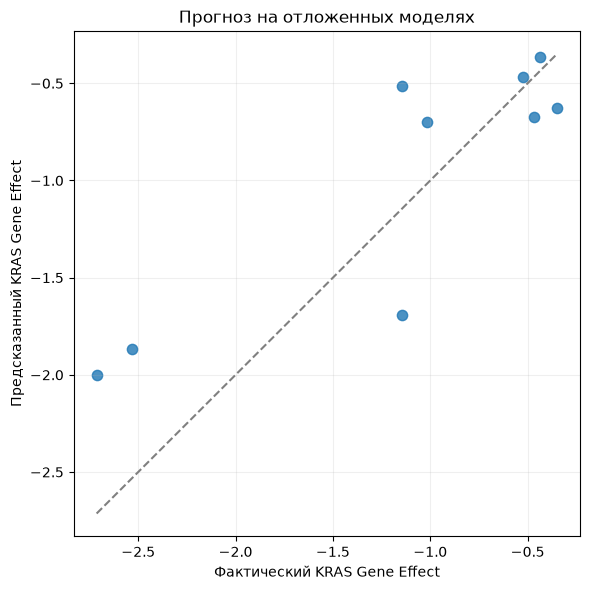

In [7]:
predictions = test[[
    "ModelID", "PatientID", "KRAS_hotspot", "PrimaryOrMetastasis",
    "SampleCollectionSite", target
]].copy()
predictions["Prediction"] = test_prediction
predictions["Baseline_prediction"] = baseline_prediction
predictions["Absolute_error"] = np.abs(predictions[target] - predictions["Prediction"])
predictions = predictions.sort_values("Absolute_error", ascending=False)

display(predictions)

low = min(y_test.min(), test_prediction.min())
high = max(y_test.max(), test_prediction.max())
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, test_prediction, s=55, alpha=0.8)
ax.plot([low, high], [low, high], linestyle="--", color="grey")
ax.set_xlabel("Фактический KRAS Gene Effect")
ax.set_ylabel("Предсказанный KRAS Gene Effect")
ax.set_title("Прогноз на отложенных моделях")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## 8. Смотрим коэффициенты

Коэффициенты показывают направление связи внутри этой линейной модели при фиксированных остальных признаках.

- отрицательный коэффициент связан с более отрицательным прогнозом;
- положительный — с более высоким прогнозом;
- размер коэффициента категориального столбца измеряется относительно удалённой базовой категории.

Коэффициенты на 46 строках нестабильны. Они не доказывают причинность и не являются окончательной «важностью» признака.


In [8]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_model.named_steps["model"].coef_,
})
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
display(coefficients.sort_values("abs_coefficient", ascending=False))


,feature,coefficient,abs_coefficient
2,categorical__KRAS_hotspot_1,-1.236584,1.236584
8,categorical__GrowthPattern_Mixed,-0.238449,0.238449
3,categorical__PrimaryOrMetastasis_Primary,0.190745,0.190745
4,categorical__SampleCollectionSite_large_intestine,-0.102237,0.102237
0,numeric__KRAS_expression,-0.089621,0.089621
5,categorical__SampleCollectionSite_infrequent_s...,0.078027,0.078027
6,categorical__Sex_Male,-0.060238,0.060238
7,categorical__Sex_infrequent_sklearn,0.033765,0.033765
1,numeric__Age,-0.009609,0.009609


## 9. LightGBM

LightGBM строит не одну линейную формулу, а последовательность небольших деревьев решений. Поэтому он может находить нелинейные зависимости и взаимодействия признаков. Например, влияние `KRAS_expression` может различаться для hotspot- и non-hotspot-моделей.

Чтобы сравнение с линейной регрессией было честным, используем те же `X_train`, `y_train`, `groups_train`, `X_test`, `y_test`, тот же preprocessing и тот же групповой `GroupKFold`. Параметры выбираются только внутри train.


In [9]:
from sklearn.base import clone
from lightgbm import LGBMRegressor

lightgbm_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=1,
        verbosity=-1,
    )),
])

# Небольшая сетка: строк мало, поэтому глубокие деревья здесь не нужны.
lightgbm_param_grid = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.03, 0.10],
    "model__num_leaves": [3, 5, 7],
    "model__min_child_samples": [3, 5, 10],
    "preprocessor__categorical__encoder__min_frequency": [2, 5],
}

lightgbm_grid = GridSearchCV(
    estimator=lightgbm_pipeline,
    param_grid=lightgbm_param_grid,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    n_jobs=1,
    return_train_score=True,
)

lightgbm_grid.fit(X_train, y_train, groups=groups_train)
best_lightgbm = lightgbm_grid.best_estimator_
lightgbm_prediction = best_lightgbm.predict(X_test)

print("Лучшие параметры LightGBM:", lightgbm_grid.best_params_)
print(f"Средняя validation MAE внутри train: {-lightgbm_grid.best_score_:.3f}")
display(pd.DataFrame({
    "LightGBM": regression_metrics(y_test, lightgbm_prediction),
    "LinearRegression": regression_metrics(y_test, test_prediction),
    "Среднее train": regression_metrics(y_test, baseline_prediction),
}).T)


Лучшие параметры LightGBM: {'model__learning_rate': 0.03, 'model__min_child_samples': 10, 'model__n_estimators': 50, 'model__num_leaves': 3, 'preprocessor__categorical__encoder__min_frequency': 2}
Средняя validation MAE внутри train: 0.500


,MAE,RMSE,R2
LightGBM,0.486419,0.533142,0.598569
LinearRegression,0.386751,0.455972,0.706369
Среднее train,0.783268,0.872611,-0.075389


## 10. XGBoost

XGBoost тоже последовательно строит деревья, но использует другой алгоритм регуляризации и оптимизации. Он проверяет ту же гипотезу: дают ли нелинейные правила лучший прогноз `KRAS_GeneEffect`, чем линейная модель и простое среднее.

Сетка намеренно небольшая. На 37 обучающих объектах большая сетка и сложные деревья легко подгонятся под случайные особенности train.


In [10]:
from xgboost import XGBRegressor

xgboost_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=42,
        n_jobs=1,
        tree_method="hist",
        verbosity=0,
    )),
])

xgboost_param_grid = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.03, 0.10],
    "model__max_depth": [1, 2, 3],
    "model__min_child_weight": [1, 5],
    "model__reg_lambda": [1, 5],
}

xgboost_grid = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=xgboost_param_grid,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    n_jobs=1,
    return_train_score=True,
)

xgboost_grid.fit(X_train, y_train, groups=groups_train)
best_xgboost = xgboost_grid.best_estimator_
xgboost_prediction = best_xgboost.predict(X_test)

print("Лучшие параметры XGBoost:", xgboost_grid.best_params_)
print(f"Средняя validation MAE внутри train: {-xgboost_grid.best_score_:.3f}")
display(pd.DataFrame({
    "XGBoost": regression_metrics(y_test, xgboost_prediction),
    "LinearRegression": regression_metrics(y_test, test_prediction),
    "Среднее train": regression_metrics(y_test, baseline_prediction),
}).T)


Лучшие параметры XGBoost: {'model__learning_rate': 0.03, 'model__max_depth': 1, 'model__min_child_weight': 5, 'model__n_estimators': 50, 'model__reg_lambda': 1}
Средняя validation MAE внутри train: 0.500


,MAE,RMSE,R2
XGBoost,0.497210,0.548470,0.575156
LinearRegression,0.386751,0.455972,0.706369
Среднее train,0.783268,0.872611,-0.075389


## 11. Сравниваем все модели на одном test

Для всех моделей считаем одинаковые метрики на одних и тех же девяти отложенных объектах:

- **MAE** — средняя абсолютная ошибка; меньше лучше;
- **RMSE** — сильнее штрафует большие ошибки; меньше лучше;
- **R²** — доля объяснённого разброса; больше лучше. Отрицательное значение означает, что модель хуже константного прогноза средним train.

Пунктир на графике показывает идеальный прогноз: чем ближе точка к линии, тем меньше ошибка.


,MAE,RMSE,R2
LinearRegression,0.386751,0.455972,0.706369
LightGBM,0.486419,0.533142,0.598569
XGBoost,0.497210,0.548470,0.575156
Среднее train,0.783268,0.872611,-0.075389


,ModelID,PatientID,KRAS_GeneEffect,LinearRegression,LightGBM,XGBoost,Среднее train
0,ACH-000552,PT-sF39aT,-0.468224,-0.672185,-0.876528,-0.891733,-1.378813
3,ACH-002669,PT-53ZOQS,-0.349134,-0.627164,-0.876528,-0.891733,-1.378813
5,ACH-000959,PT-ulmNPq,-1.018418,-0.699624,-0.876528,-0.891733,-1.378813
6,ACH-000986,PT-EoHcfh,-1.145164,-0.514016,-0.876528,-0.891733,-1.378813
7,ACH-000943,PT-9E5O4L,-0.521471,-0.467103,-0.876528,-0.891733,-1.378813
12,ACH-000252,PT-XQHvQF,-2.713382,-2.000203,-1.823103,-1.791094,-1.378813
15,ACH-000501,PT-kCvNaO,-1.147304,-1.693391,-1.788407,-1.791094,-1.378813
34,ACH-002654,PT-anuBoi,-2.529257,-1.868171,-1.823103,-1.791094,-1.378813
37,ACH-000935,PT-snQqpb,-0.437574,-0.363469,-0.876528,-0.891733,-1.378813


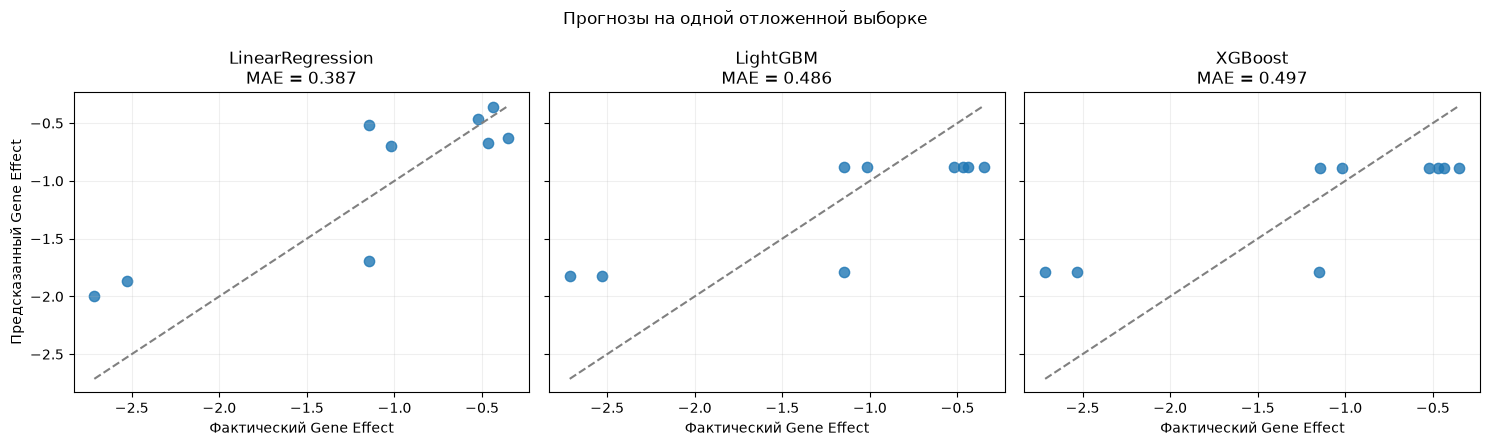

In [11]:
prediction_by_model = {
    "LinearRegression": test_prediction,
    "LightGBM": lightgbm_prediction,
    "XGBoost": xgboost_prediction,
    "Среднее train": baseline_prediction,
}

comparison_metrics = pd.DataFrame({
    name: regression_metrics(y_test, prediction)
    for name, prediction in prediction_by_model.items()
}).T.sort_values("MAE")
display(comparison_metrics)

comparison_predictions = test[["ModelID", "PatientID", target]].copy()
for name, prediction in prediction_by_model.items():
    comparison_predictions[name] = prediction
display(comparison_predictions)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
tree_predictions = {
    "LinearRegression": test_prediction,
    "LightGBM": lightgbm_prediction,
    "XGBoost": xgboost_prediction,
}
all_values = np.concatenate([
    y_test.to_numpy(), test_prediction, lightgbm_prediction, xgboost_prediction
])
low, high = all_values.min(), all_values.max()

for ax, (name, prediction) in zip(axes, tree_predictions.items()):
    ax.scatter(y_test, prediction, s=55, alpha=0.8)
    ax.plot([low, high], [low, high], linestyle="--", color="grey")
    ax.set_title(f"{name}\nMAE = {comparison_metrics.loc[name, 'MAE']:.3f}")
    ax.set_xlabel("Фактический Gene Effect")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Предсказанный Gene Effect")
fig.suptitle("Прогнозы на одной отложенной выборке")
fig.tight_layout()
plt.show()


## 12. Какие признаки использовали деревья

`feature_importances_` показывает, какие признаки деревья чаще использовали для уменьшения ошибки. Это полезно для разведочного анализа, но не доказывает причинное влияние признака на зависимость от KRAS. При таком маленьком датасете порядок важности может заметно измениться после другой разбивки.


In [12]:
def feature_importance_table(fitted_pipeline, model_name):
    names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    values = fitted_pipeline.named_steps["model"].feature_importances_
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .assign(model=model_name)
        .sort_values("importance", ascending=False)
    )

tree_importances = pd.concat([
    feature_importance_table(best_lightgbm, "LightGBM"),
    feature_importance_table(best_xgboost, "XGBoost"),
], ignore_index=True)

display(tree_importances.groupby("model", group_keys=False).head(10))


,feature,importance,model
0,numeric__KRAS_expression,50.000000,LightGBM
1,categorical__KRAS_hotspot_1,50.000000,LightGBM
2,numeric__Age,0.000000,LightGBM
3,categorical__PrimaryOrMetastasis_Primary,0.000000,LightGBM
4,categorical__SampleCollectionSite_ascites,0.000000,LightGBM
5,categorical__SampleCollectionSite_large_intestine,0.000000,LightGBM
6,categorical__SampleCollectionSite_lymph_node,0.000000,LightGBM
7,categorical__SampleCollectionSite_infrequent_s...,0.000000,LightGBM
8,categorical__Sex_Male,0.000000,LightGBM
9,categorical__Sex_Unknown,0.000000,LightGBM


## 13. Ограничения результата

Этот pipeline проверяет техническую возможность прогноза на очень маленьком наборе. Один test содержит около девяти моделей. Поэтому вывод по нему предварительный.

Особенно важно:

- GridSearch выбирает лучший вариант только внутри train;
- один и тот же test использован для сравнения трёх моделей, поэтому выбирать по нему окончательного победителя пока нельзя;
- одна случайная разбивка может дать нестабильный результат;
- редкие места получения образца создают категории из одной-двух моделей;
- метаданные могут описывать происхождение модели, но не обязательно причинно влияют на зависимость от KRAS;
- деревья способны запоминать особенности маленького train, поэтому сравнивайте train/validation MAE и test MAE;
- для более надёжной оценки следующим шагом нужна вложенная повторная проверка по группам пациентов;
- для регуляризации большого числа признаков лучше перейти к Ridge, у которого есть содержательный параметр `alpha`.
